In [208]:
import pandas as pd
from seismostats import Catalog
import matplotlib.pyplot as plt
import numpy as np
import warnings
import tqdm

%config InlineBackend.figure_format ='retina'


In [209]:
# paramters
delta_m = 0.01
dmc = 0.1

correction_factor = 0.2
fmd_bin = 0.1

## get data

In [210]:
# ML high resoution catalog

location = 'data/training/Amatrice_CAT5_train.csv'
cat_raw = pd.read_csv(location)

cat_train = Catalog(cat_raw)
cat_train.delta_m = delta_m

In [211]:
cat_train['time'][1]

Timestamp('2016-08-15 01:42:44.947000')

<Axes: xlabel='Time', ylabel='Magnitude'>

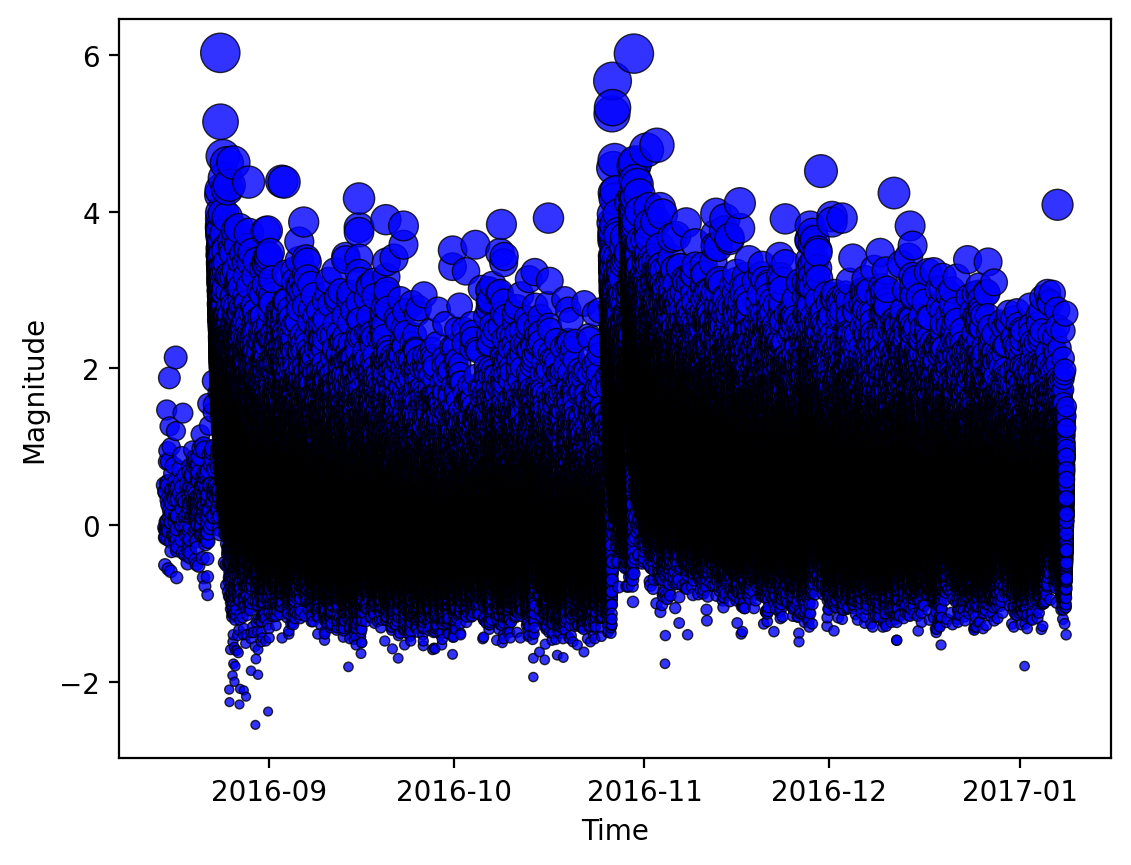

In [212]:
cat_train.plot_mags_in_time()

(-10.0, 35.0)

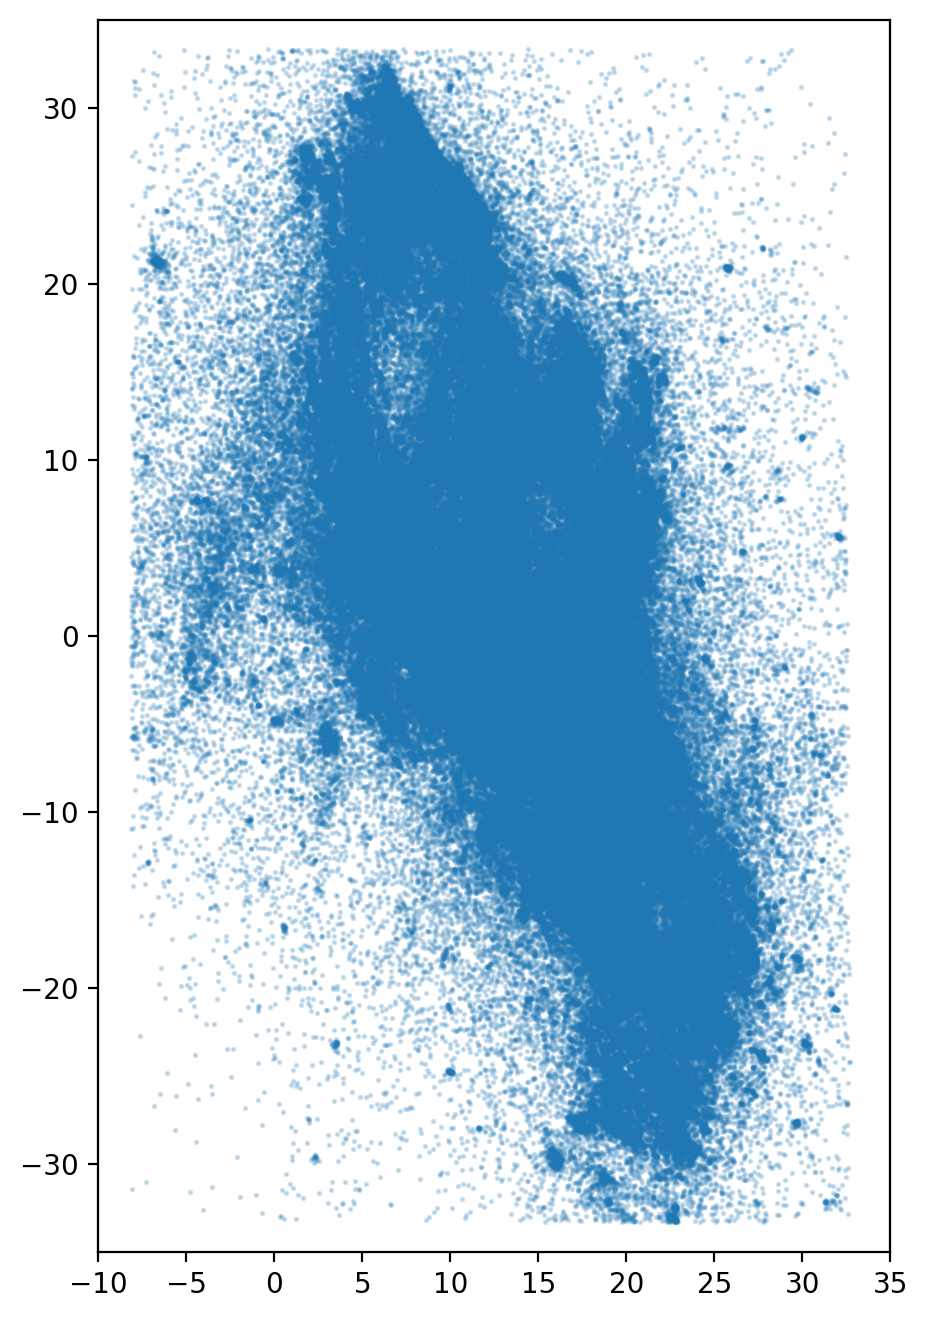

In [213]:
import numpy as np

# make ax cartopy geoaxis
import cartopy.crs as ccrs
fig = plt.figure(figsize=(12, 8))
plt.scatter(cat_train.y, cat_train.x, s=1, alpha=0.2)

#equal axis
plt.gca().set_aspect('equal', adjustable='box')

#equal axis
plt.gca().set_aspect('equal', adjustable='box')

# limit depth to 30 km
plt.ylim(-35, 35)
# limit x to 20 km
plt.xlim(-10, 35)

(-10.0, 35.0)

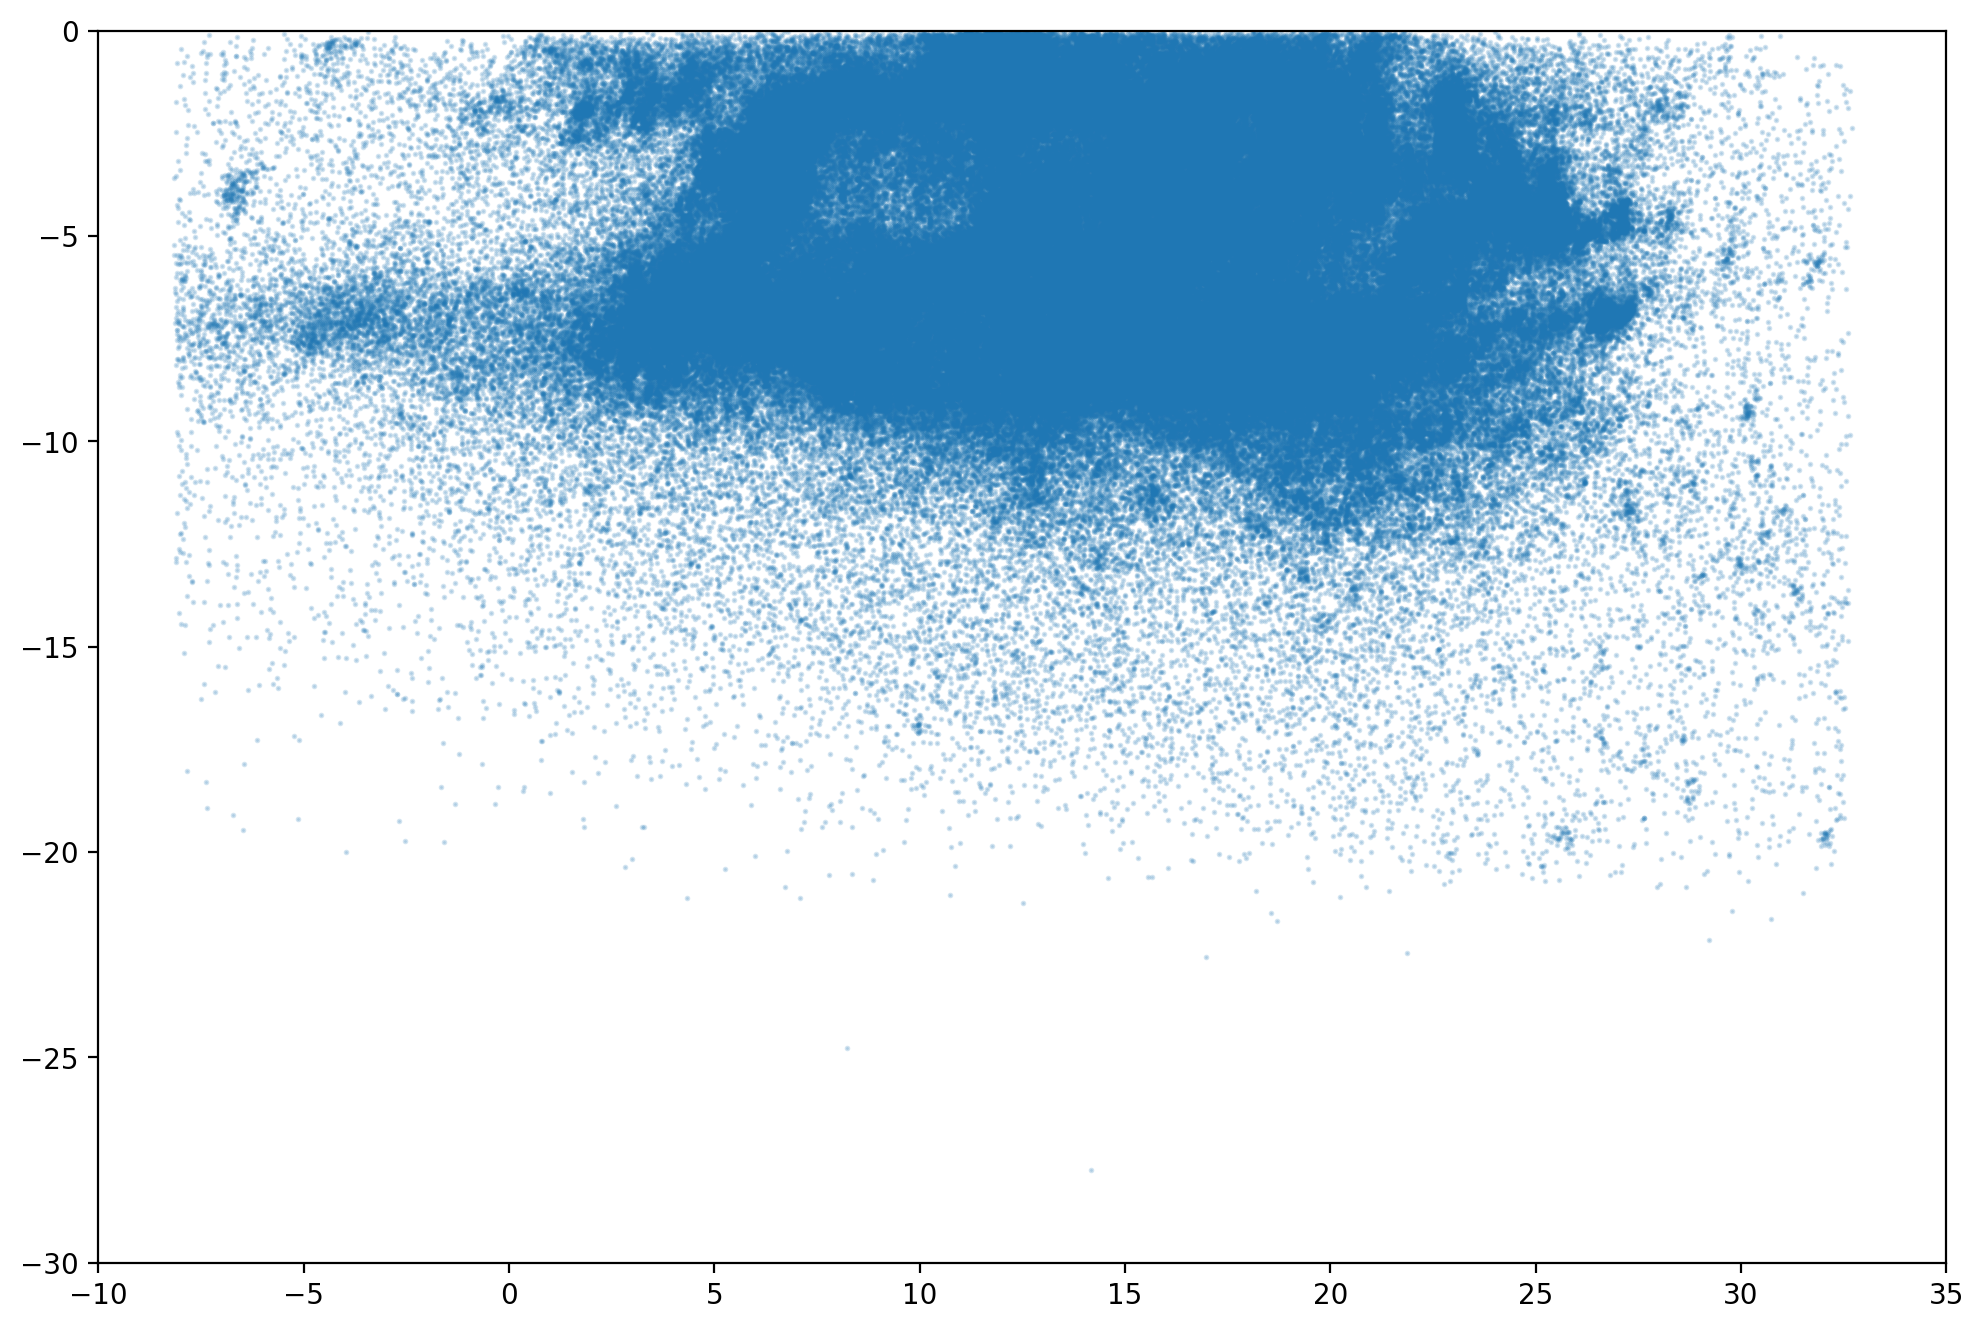

In [214]:
import numpy as np

# make ax cartopy geoaxis
import cartopy.crs as ccrs
fig = plt.figure(figsize=(12, 8))
plt.scatter(cat_train.y, cat_train.z, s=1, alpha=0.2)

#equal axis
plt.gca().set_aspect('equal', adjustable='box')

# limit depth to 30 km
plt.ylim(-30, 0)
# limit x to 20 km
plt.xlim(-10, 35)

Legend added to the plot.
Mc: 0.30


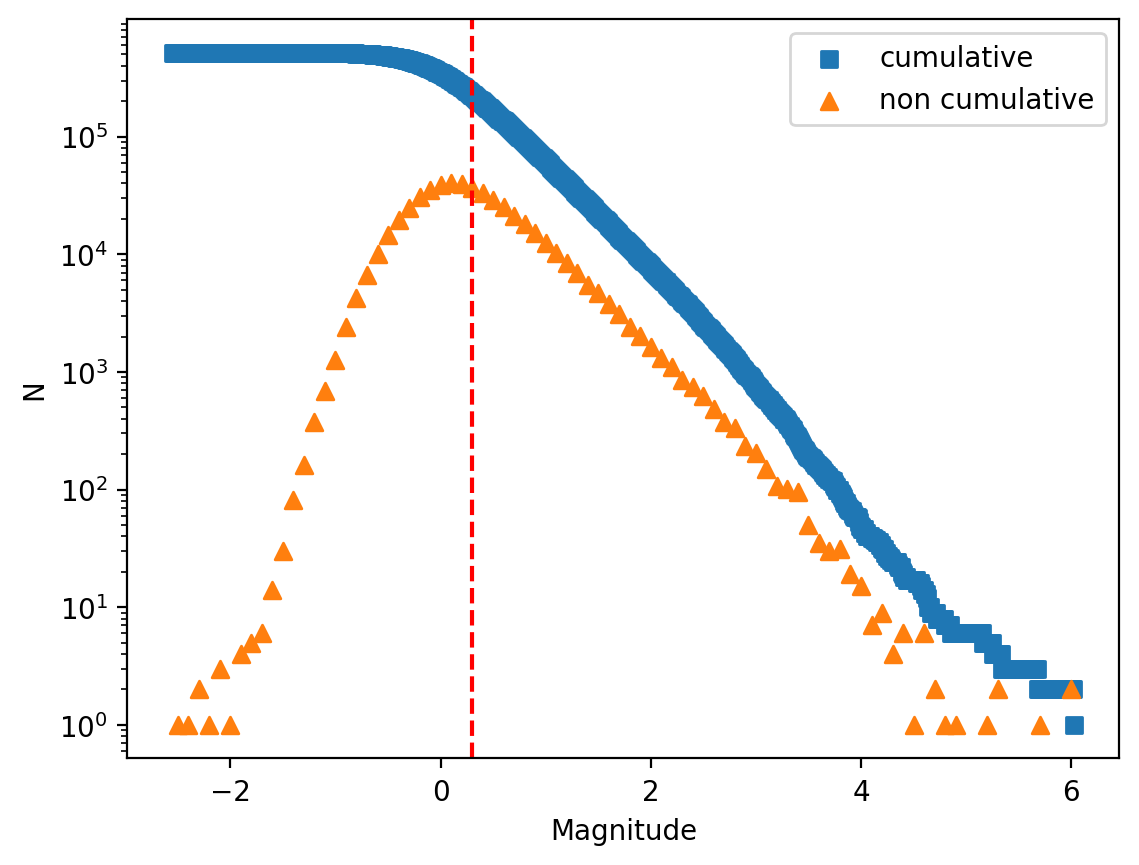

In [215]:
ax = cat_train.plot_cum_fmd()
cat_train.plot_fmd(ax = ax, fmd_bin=0.1)

cat_train.estimate_mc_maxc(fmd_bin=0.1)
plt.axvline(cat_train.mc, color='red', label='Mc', linestyle='--')
print(f'Mc: {cat_train.mc:.2f}')

# make map

In [216]:
from seismostats.utils import bin_to_precision

# cutoff all events below Mc
cat_train = cat_train[cat_train.magnitude >= cat_train.mc]

# sort in time
cat_train = cat_train.sort_values('time').reset_index(drop=True)

# create the magnitude differences
cat_train.magnitude = bin_to_precision(cat_train['magnitude'].diff(), delta_m)
nan_idx = cat_train.magnitude.isna()
cat_train = cat_train[~nan_idx]

idx = cat_train.magnitude > dmc - delta_m/2
cat_train = cat_train[idx].reset_index(drop=True)

cat_train.mc = dmc

In [217]:
cat_train.magnitude.min()

np.float64(0.1)

In [218]:
import itertools
# 3D grid
# coords and limits
coords = [cat_train.x.values, cat_train.y.values, cat_train.z.values]

limits = [[min(coord), max(coord)] for coord in coords]

# create grid for evaluation
delta = 1 # in km
x_vec = np.arange(limits[0][0], limits[0][1], delta)
y_vec = np.arange(limits[1][0], limits[1][1], delta)
z_vec = np.arange(limits[2][0], limits[2][1], delta)

grid = np.array(list(itertools.product(x_vec, y_vec, z_vec)))
grid = grid.T

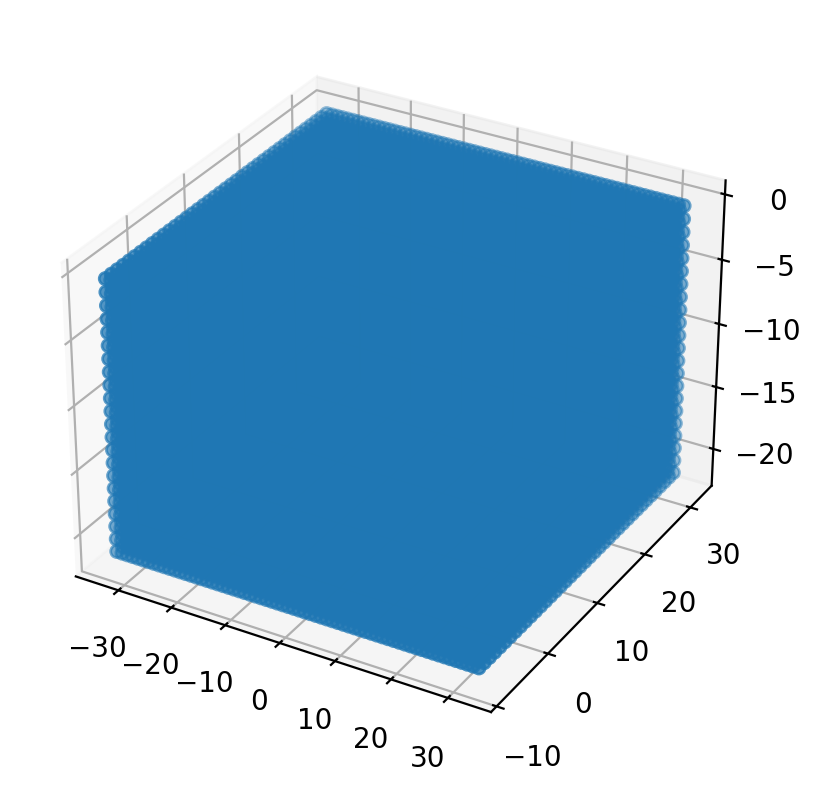

In [219]:
ax = plt.axes(projection='3d')
ax.scatter(grid[0], grid[1], grid[2])

# length scale analysis

In [220]:
volume = (limits[0][1] - limits[0][0]) * (limits[1][1] - limits[1][0]) * (limits[2][1] - limits[2][0])
n_space = 1024
cell_volume = volume / n_space

cell_radius = (cell_volume/np.pi * 3/4)**(1/3)
print('radius of the cells: {:.2f} km'.format(cell_radius))


radius of the cells: 2.39 km


In [221]:
print(cat_train.mc)

0.1


In [222]:
cat_train.b_value

Legend added to the plot.


Text(0.5, 0, 'Magnitude differences')

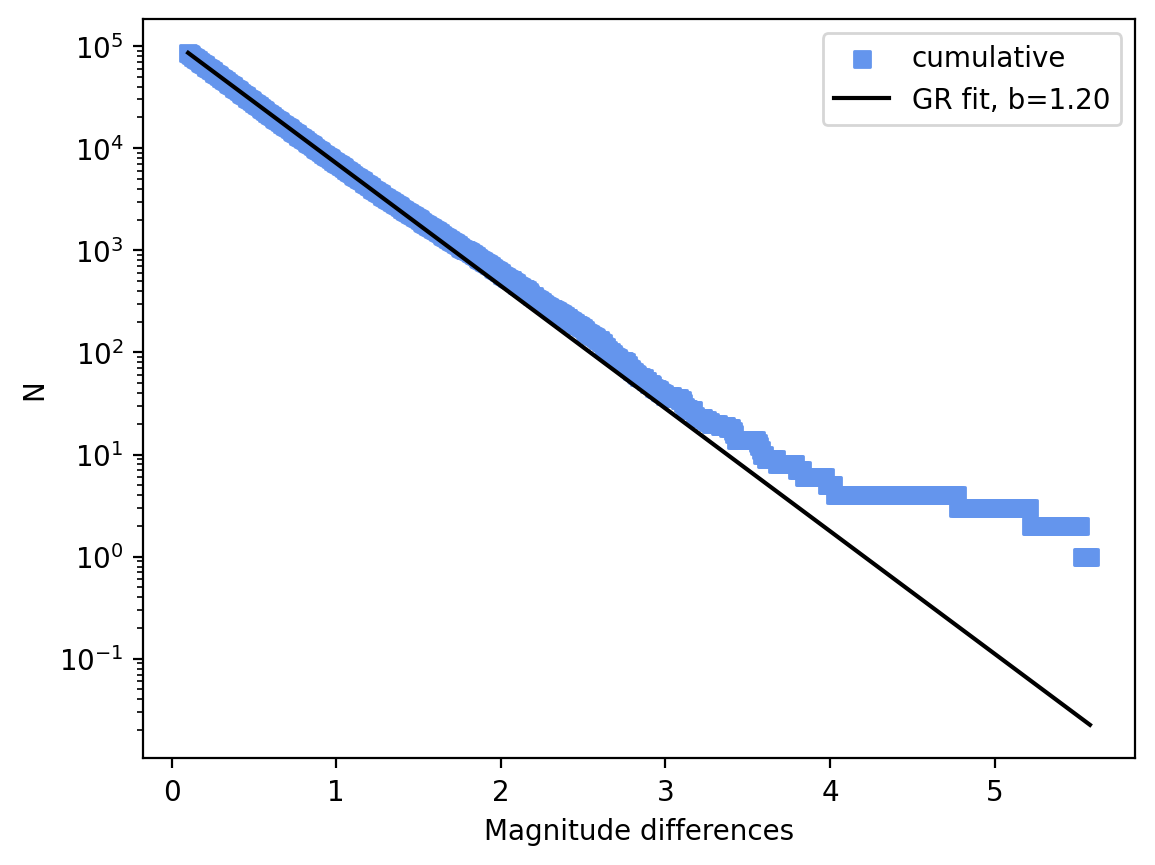

In [223]:
cat_train.estimate_b()

cat_train.plot_cum_fmd(b_value = cat_train.b_value, color='cornflowerblue', color_line='k')
plt.xlabel('Magnitude differences')


In [224]:
from functions.space_map import mac_space
from seismostats.analysis import ClassicBValueEstimator, estimate_mc_maxc

def estimate_mc(magnitudes):
    mc, _ = estimate_mc_maxc(magnitudes, fmd_bin=fmd_bin,
                             correction_factor=correction_factor)
    return mc


warnings.filterwarnings('ignore')
b_average_1, b_std_1, mac_spatial_1, mu_mac_spatial_1, std_mac_spatial_1 = mac_space(
    coords = coords,
    mags = cat_train.magnitude,
    delta_m = cat_train.delta_m,
    times = cat_train.time,
    limits = limits,
    n_space=n_space,
    n_realizations=100,
    eval_coords= grid,
    min_num=50,
    method = ClassicBValueEstimator,
    mc = dmc,
    transform=True,
    voronoi_method='random',
    min_count=20,
)

warnings.filterwarnings('default')

In [225]:
# choose slices
depth_slice_km = 8
depth_slice = -depth_slice_km
east_slice = 15

top_mask = (grid[2] >= depth_slice - 2 * delta) & (grid[2] < depth_slice + 2 * delta)
depth_mask = (grid[1] >= east_slice - delta) & (grid[1] < east_slice + delta)

reference_cat = pd.concat(
    [
        cat_train.copy(),
        pd.read_csv('data/testing/Amatrice_CAT5_test.csv'),
    ],
    ignore_index=True,
)
reference_cat['time'] = pd.to_datetime(reference_cat['time'])

mainshock_times = [
    ('Amatrice', pd.Timestamp('2016-08-24 01:36:32')),
    ('Visso', pd.Timestamp('2016-10-26 19:18:06')),
    ('Norcia', pd.Timestamp('2016-10-30 06:40:17')),
]

campotosto_times = [
    ('Campotosto 1', pd.Timestamp('2017-01-18 09:25:41')),
    ('Campotosto 2', pd.Timestamp('2017-01-18 10:14:10')),
    ('Campotosto 3', pd.Timestamp('2017-01-18 10:25:23')),
    ('Campotosto 4', pd.Timestamp('2017-01-18 13:33:37')),
]


def select_nearest_event(cat_df, target_time, max_dt='5s'):
    dt = (cat_df['time'] - target_time).abs()
    idx = dt.idxmin()
    if dt.loc[idx] > pd.Timedelta(max_dt):
        raise ValueError(f'No event found within {max_dt} of {target_time}.')
    return cat_df.loc[idx]


def select_campotosto_event(cat_df, target_time):
    window_start = target_time - pd.Timedelta(seconds=3)
    hits = cat_df[
        (cat_df['time'] > window_start)
        & (cat_df['time'] < window_start + pd.Timedelta(seconds=10))
        & (cat_df['magnitude'] > 5)
    ]
    if not hits.empty:
        return hits.sort_values('magnitude', ascending=False).iloc[0]

    fallback = cat_df.loc[(cat_df['time'] - target_time).abs().idxmin()]
    return fallback


highlight_events = []
for name, event_time in mainshock_times:
    event = select_nearest_event(reference_cat, event_time).copy()
    event['event_name'] = name
    event['event_group'] = 'mainshock'
    highlight_events.append(event)

for name, event_time in campotosto_times:
    event = select_campotosto_event(reference_cat, event_time).copy()
    event['event_name'] = name
    event['event_group'] = 'campotosto'
    highlight_events.append(event)

highlight_events = pd.DataFrame(highlight_events)



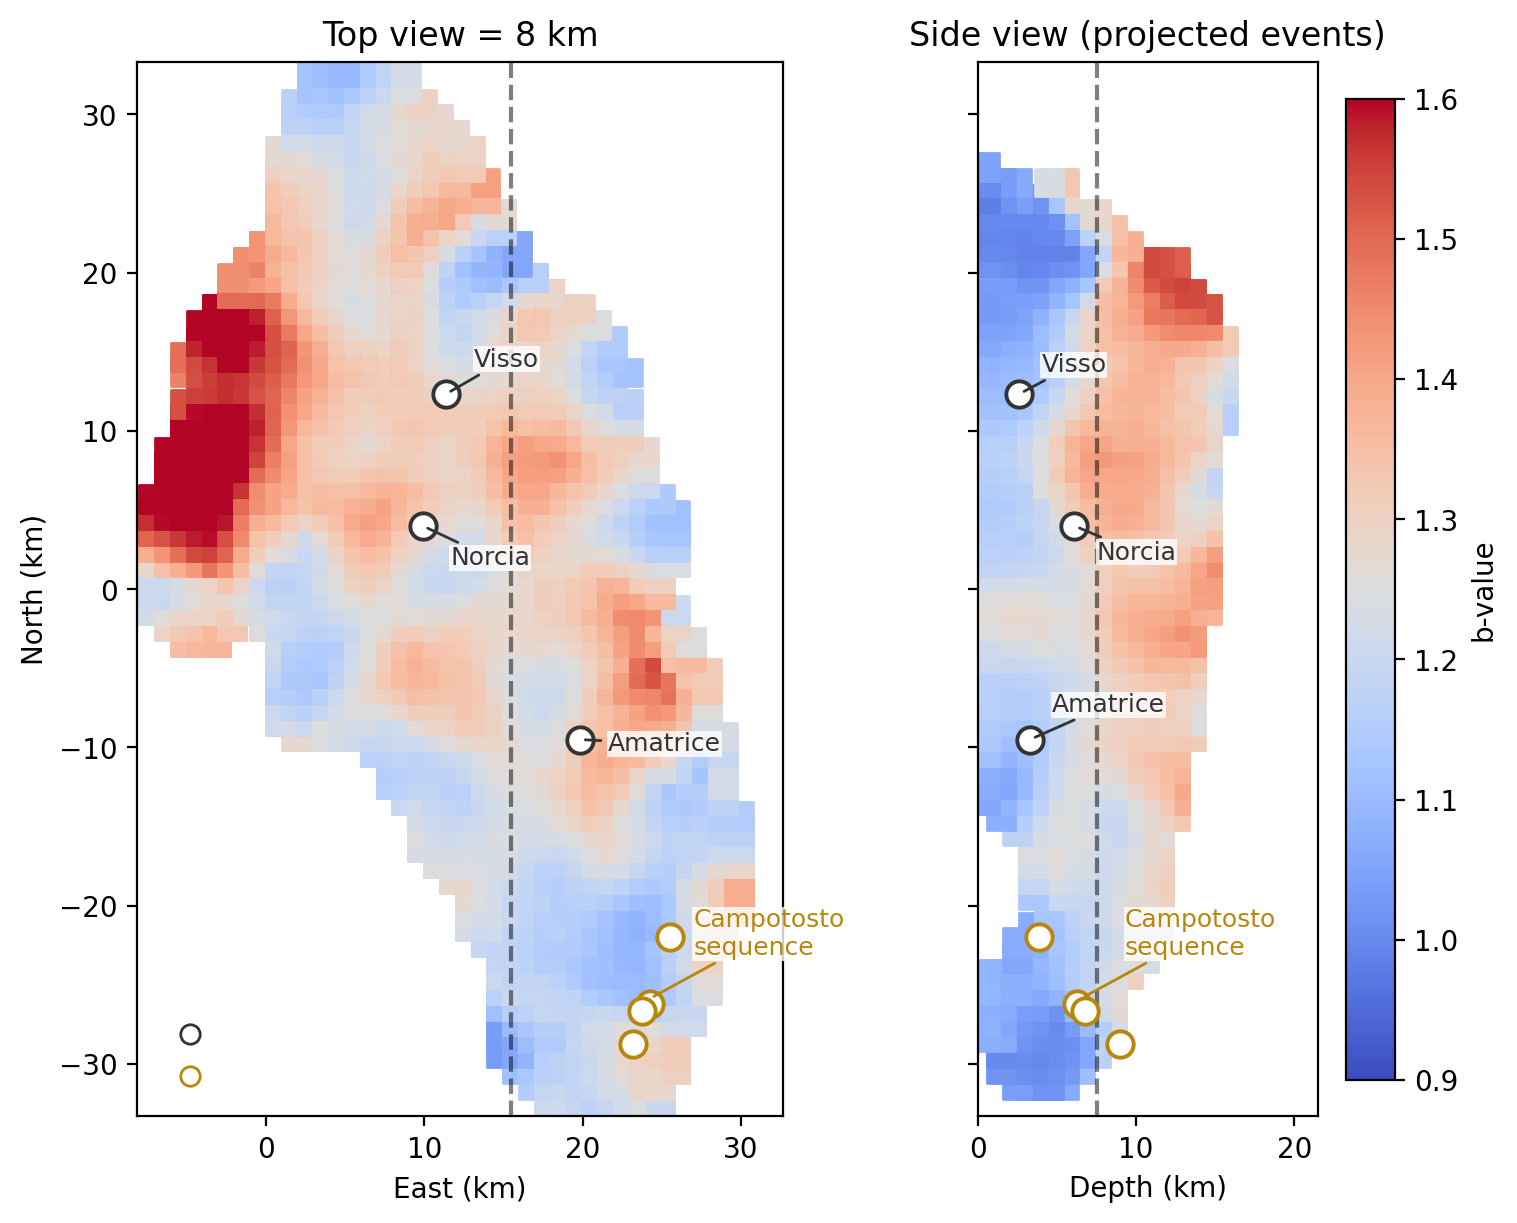

In [228]:
from matplotlib.lines import Line2D

vmin, vmax = 0.9, 1.6
east_span = limits[1][1] - limits[1][0]
depth_limits = [-limits[2][1], -limits[2][0]]
depth_span = depth_limits[1] - depth_limits[0]

fig, (ax_top, ax_depth) = plt.subplots(
    1,
    2,
    figsize=(8, 6),
    sharey=True,
    constrained_layout=True,
    gridspec_kw={'width_ratios': [east_span, depth_span]},
)

sc = ax_top.scatter(
    grid[1, top_mask],
    grid[0, top_mask],
    c=b_average_1[top_mask],
    cmap='coolwarm',
    marker='s',
    s=100,
    vmin=vmin,
    vmax=vmax,
)

ax_depth.scatter(
    -grid[2, depth_mask],
    grid[0, depth_mask],
    c=b_average_1[depth_mask],
    cmap='coolwarm',
    marker='s',
    s=100,
    vmin=vmin,
    vmax=vmax,
)

mainshock_events = highlight_events[highlight_events['event_group'] == 'mainshock']
campotosto_events = highlight_events[highlight_events['event_group'] == 'campotosto']

ax_top.scatter(
    mainshock_events.y,
    mainshock_events.x,
    s=90,
    facecolors='white',
    edgecolors='0.2',
    linewidths=1.4,
    zorder=4,
)
ax_top.scatter(
    campotosto_events.y,
    campotosto_events.x,
    s=90,
    facecolors='white',
    edgecolors='darkgoldenrod',
    linewidths=1.4,
    zorder=4,
)

ax_depth.scatter(
    -mainshock_events.z,
    mainshock_events.x,
    s=90,
    facecolors='white',
    edgecolors='0.2',
    linewidths=1.4,
    zorder=4,
)
ax_depth.scatter(
    -campotosto_events.z,
    campotosto_events.x,
    s=90,
    facecolors='white',
    edgecolors='darkgoldenrod',
    linewidths=1.4,
    zorder=4,
)

top_label_offsets = {
    'Amatrice': (10, -4),
    'Visso': (10, 10),
    'Norcia': (10, -14),
}
side_label_offsets = {
    'Amatrice': (8, 10),
    'Visso': (8, 8),
    'Norcia': (8, -12),
}

for _, event in mainshock_events.iterrows():
    dx, dy = top_label_offsets[event['event_name']]
    ax_top.annotate(
        event['event_name'],
        xy=(event.y, event.x),
        xytext=(dx, dy),
        textcoords='offset points',
        fontsize=9,
        color='0.2',
        arrowprops=dict(arrowstyle='-', color='0.2', linewidth=1.0),
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=0.4),
        zorder=5,
    )

for _, event in mainshock_events.iterrows():
    dx, dy = side_label_offsets[event['event_name']]
    ax_depth.annotate(
        event['event_name'],
        xy=(-event.z, event.x),
        xytext=(dx, dy),
        textcoords='offset points',
        fontsize=9,
        color='0.2',
        arrowprops=dict(arrowstyle='-', color='0.2', linewidth=1.0),
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=0.4),
        zorder=5,
    )

campotosto_top_center = campotosto_events[['y', 'x']].mean()
ax_top.annotate(
    'Campotosto\nsequence',
    xy=(campotosto_top_center['y'], campotosto_top_center['x']),
    xytext=(16, 16),
    textcoords='offset points',
    fontsize=9,
    color='darkgoldenrod',
    arrowprops=dict(arrowstyle='-', color='darkgoldenrod', linewidth=1.0),
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=0.4),
    zorder=5,
)

campotosto_side_center = pd.Series({
    'depth': (-campotosto_events.z).mean(),
    'north': campotosto_events.x.mean(),
})
ax_depth.annotate(
    'Campotosto\nsequence',
    xy=(campotosto_side_center['depth'], campotosto_side_center['north']),
    xytext=(16, 16),
    textcoords='offset points',
    fontsize=9,
    color='darkgoldenrod',
    arrowprops=dict(arrowstyle='-', color='darkgoldenrod', linewidth=1.0),
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=0.4),
    zorder=5,
)

ax_top.set_xlim(limits[1][0], limits[1][1])
ax_depth.set_xlim(depth_limits[0], depth_limits[1])

for ax in (ax_top, ax_depth):
    ax.set_ylim(limits[0][0], limits[0][1])
    ax.set_aspect('equal', adjustable='box')

ax_top.set_xlabel('East (km)')
ax_top.set_ylabel('North (km)')
ax_top.set_title(f'Top view = {depth_slice_km} km')
ax_top.axvline(east_slice + delta/2, color='k', linestyle='--', alpha=0.5)

ax_depth.set_xlabel('Depth (km)')
ax_depth.set_title('Side view (projected events)')
ax_depth.tick_params(labelleft=False)
ax_depth.axvline(-depth_slice - delta/2, color='k', linestyle='--', alpha=0.5)

legend_handles = [
    Line2D([0], [0], marker='o', linestyle='', markersize=7,
           markerfacecolor='white', markeredgecolor='0.2'),
    Line2D([0], [0], marker='o', linestyle='', markersize=7,
           markerfacecolor='white', markeredgecolor='darkgoldenrod'),
]
ax_top.legend(handles=legend_handles, frameon=False, loc='lower left')

fig.colorbar(sc, ax=[ax_top, ax_depth], label='b-value', fraction=0.035, pad=0.02)


